In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

#### Wczytanie zbioru danych

In [3]:
X_train = pd.read_csv('data/train.csv')
X_test = pd.read_csv('data/test.csv')
y_train = X_train.pop('Churn') 
X_train['is_train'] = 1
X_test['is_train'] = 0
merged = pd.concat([X_train, X_test], ignore_index=True)
merged.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,is_train
848844,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65,0
848845,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50,0
848846,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75,0
848847,848847,Female,0,No,No,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25,0
848848,848848,Female,0,No,No,24,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),90.10,2172.05,0


In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [5]:
X_train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
is_train            0
dtype: int64

#### Wstępnie nie ma braków

### Porównanie rozkładów train oraz test

In [6]:
numeric_cols = merged.select_dtypes(include=['number']).columns

print(merged[numeric_cols].groupby('is_train').mean().T)

is_train                    0              1
id              721521.000000  297096.500000
SeniorCitizen        0.113620       0.114102
tenure              37.279716      36.577258
MonthlyCharges      66.130803      65.866223
TotalCharges      2544.617351    2494.377057


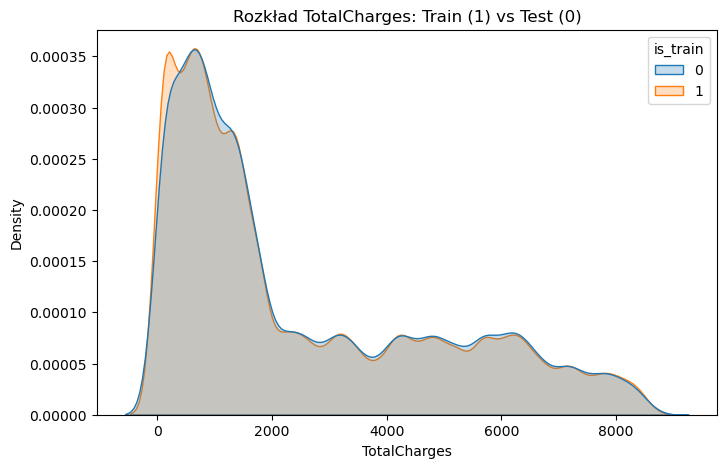

In [7]:
col_to_check = 'TotalCharges' 

plt.figure(figsize=(8, 5))
sns.kdeplot(data=merged, x=col_to_check, hue='is_train', common_norm=False, fill=True)
plt.title(f'Rozkład {col_to_check}: Train (1) vs Test (0)')
plt.show()

### Trening modelu do rozponania train vs test

In [8]:
features = merged.select_dtypes(include=['number']).drop(columns=['is_train', 'id'])


In [9]:
target = merged['is_train']

In [10]:
clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

cv_scores = cross_val_score(
    clf, features, target, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"\nŚredni wynik ROC AUC: {cv_scores.mean():.4f}")


Średni wynik ROC AUC: 0.5103


##### Dane mają bardzo zbliżone rozkłady

#### Sprawdzenie balansu klas

In [11]:
train_eda = merged[merged['is_train'] == 1].copy()
train_eda['Churn'] = y_train.values

C:\Users\micae\AppData\Local\Temp\ipykernel_14284\2566564515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_eda, x='Churn', palette='Set2')


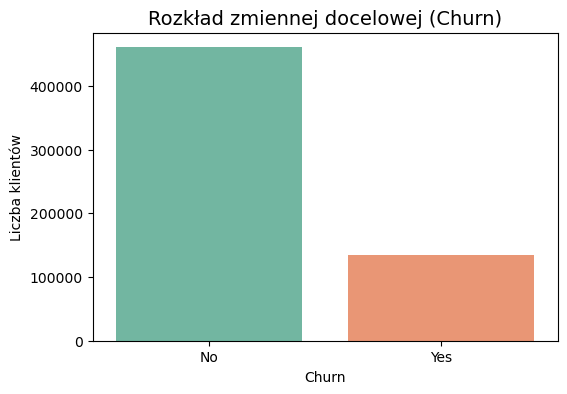

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_eda, x='Churn', palette='Set2')
plt.title('Rozkład zmiennej docelowej (Churn)', fontsize=14)
plt.ylabel('Liczba klientów')
plt.show()

#### Rozkłady zmiennych ilościowych

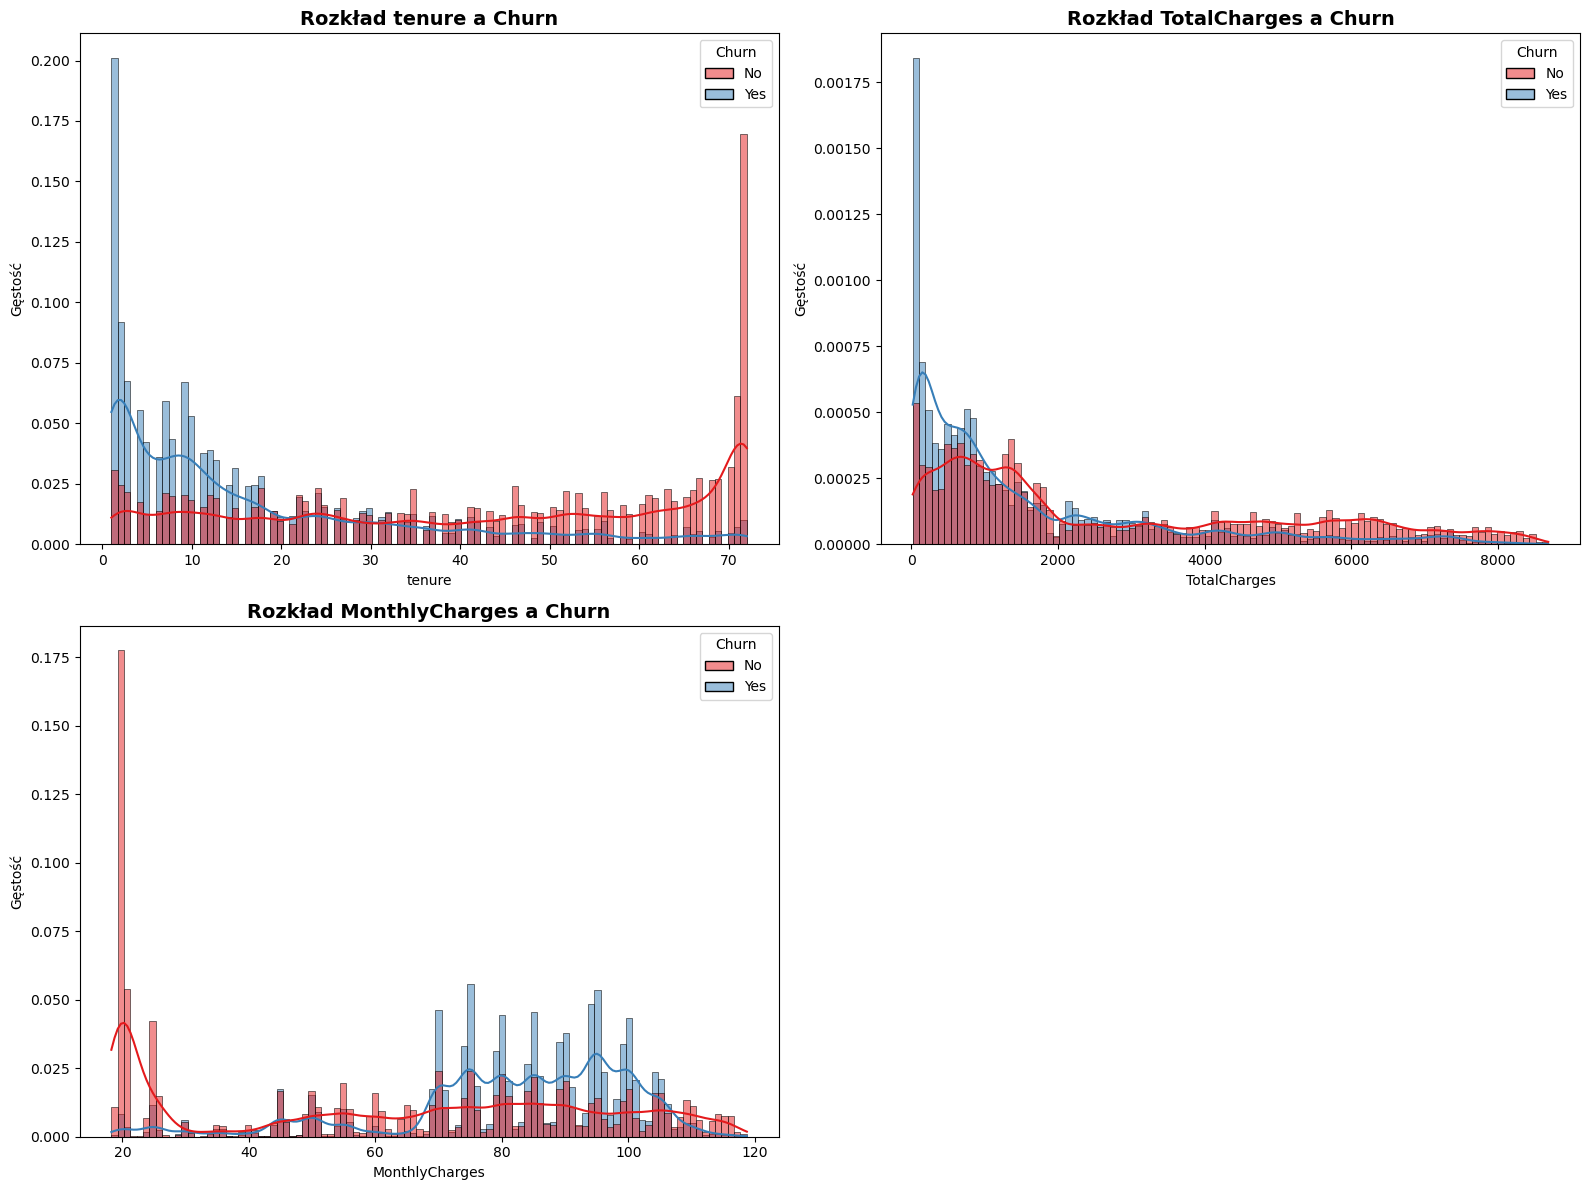

In [13]:
num_vars = ['tenure', 'TotalCharges', 'MonthlyCharges']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    if col in train_eda.columns:
        sns.histplot(
            data=train_eda, 
            x=col, 
            hue='Churn', 
            bins=100,      
            kde=True,    
            palette='Set1',    
            ax=axes[i],
            alpha=0.5,     
            common_norm=False,  
            stat='density'     
        )
        axes[i].set_title(f'Rozkład {col} a Churn', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Gęstość')
        axes[i].set_xlabel(col) 

fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

##### Tenure wygląda jak mocny predyktor

#### Macierz korelacji

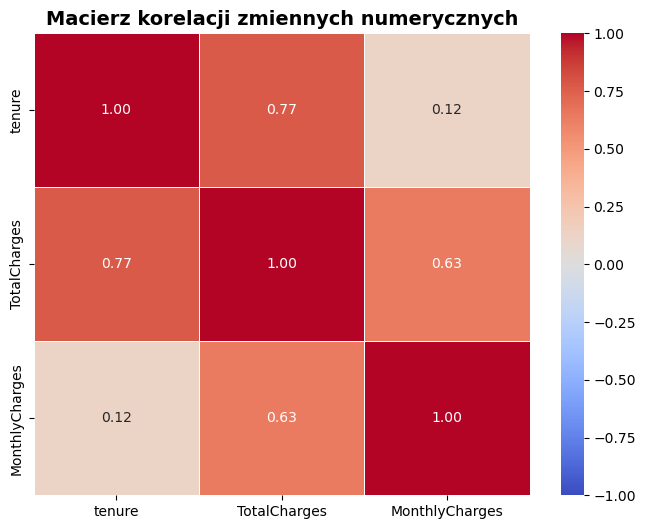

In [14]:
corr_matrix = train_eda[num_vars].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix, 
    annot=True,         
    cmap='coolwarm',   
    fmt=".2f",        
    vmin=-1, vmax=1,   
    linewidths=0.5
)
plt.title('Macierz korelacji zmiennych numerycznych', fontsize=14, fontweight='bold')
plt.show()

##### Total Charges ma spore korelacje z pozostałymi zmiennymi numerycznymi - potencjalnie lepiej stworzyć nowe cechy
Tenure - staż klienta

Monthly Charges - miesięczne opłaty

TotalCharges - całkowite opłaty

Potencjalnie można dodać total - monthly * tenure - jak zmienialy sie ceny klienta (czy dostawał jakieś zniżki?)

### Nielogiczne, warunkowe braki i wartości odstające

In [15]:
unlogical_zeros = merged[(merged['TotalCharges'] == 0) & (merged['tenure'] > 0)]
print(f"Liczba nielogicznych zer: {len(unlogical_zeros)}")

Liczba nielogicznych zer: 0


In [16]:
ile_ujemnych = (merged['TotalCharges'] < 0).sum()
print(ile_ujemnych)

0


In [17]:
merged['TotalCharges'].value_counts()

TotalCharges
6096.90    1206
1110.05    1182
6448.05    1049
854.90     1045
7133.25     902
           ... 
657.80        1
110.95        1
3566.30       1
3766.05       1
1238.70       1
Name: count, Length: 35209, dtype: int64

##### Nie wygląda podejrzanie

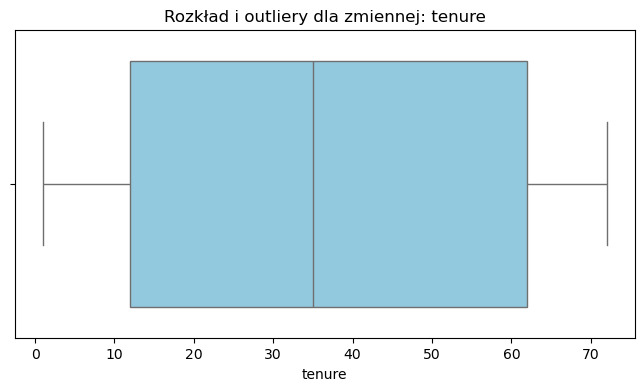

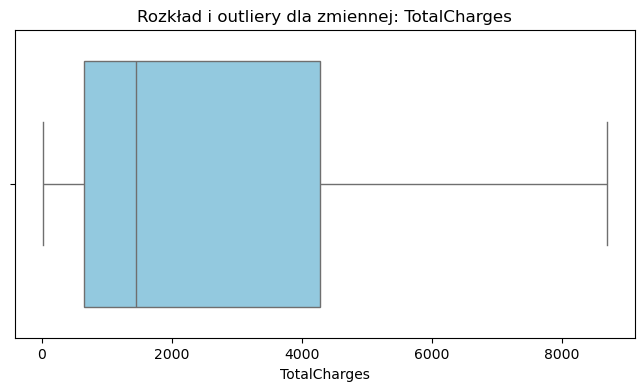

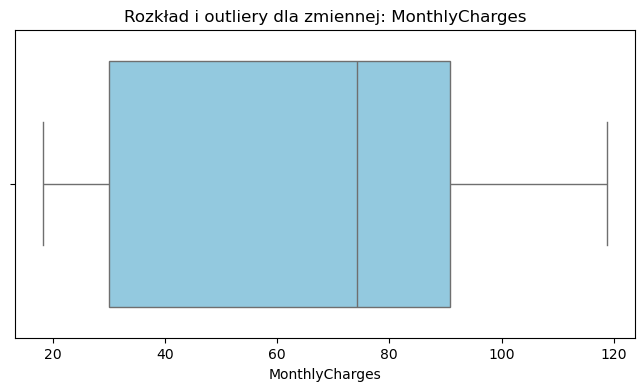

In [18]:
for var in num_vars:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=merged[var], color='skyblue')

    plt.title(f'Rozkład i outliery dla zmiennej: {var}')

    plt.show()

##### Brak outlierów

#### Wykresy punktowe dla zmiennych numerycznych

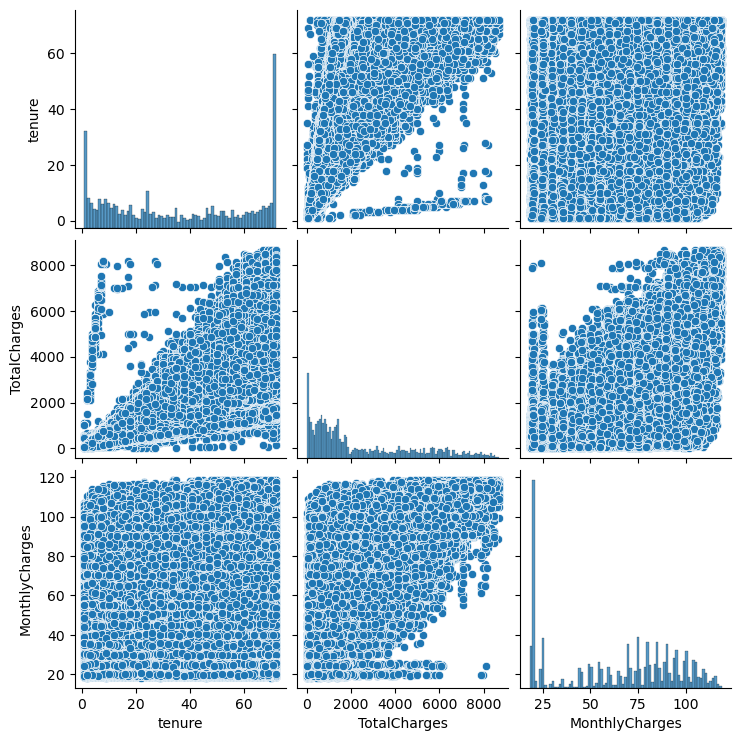

In [19]:
sns.pairplot(merged[num_vars])

#### Wpływy pojedynczych danych kategorycznych

In [20]:
zmienne_do_testu = [
    'InternetService', 'PaymentMethod', 'TechSupport', 'Contract', 'gender', 'SeniorCitizen', 'Partner',
    'OnlineSecurity', 'OnlineBackup', 'PhoneService', 'MultipleLines', 'Dependents',
    'DeviceProtection', 'PaperlessBilling', 'StreamingMovies', 'StreamingTV'
]

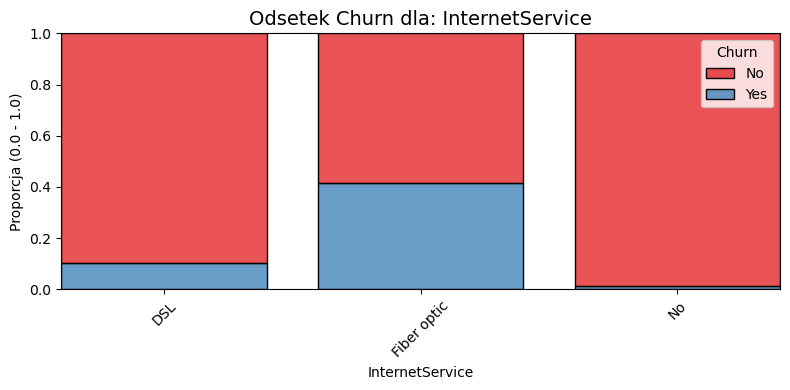

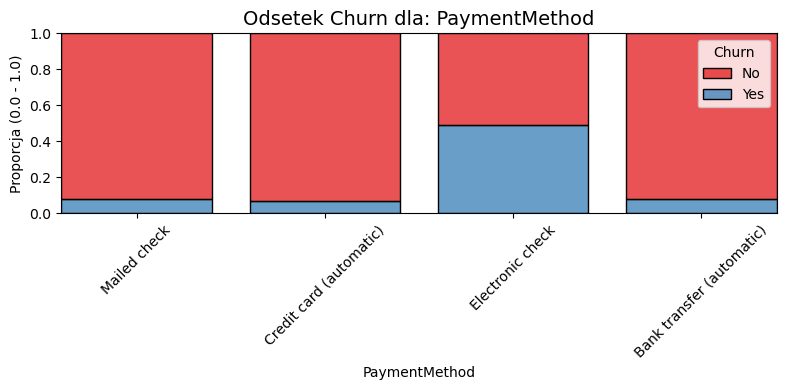

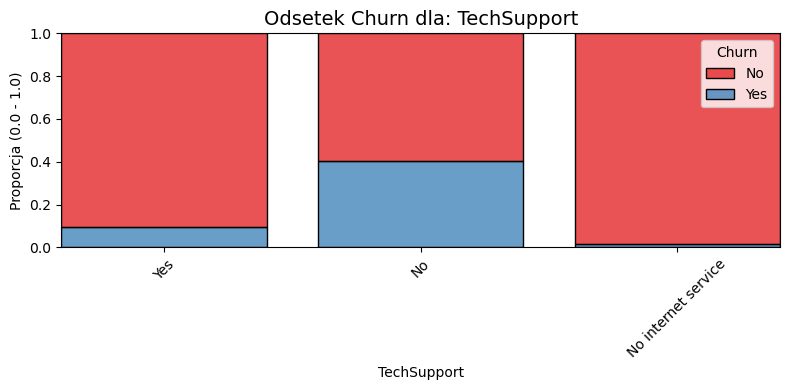

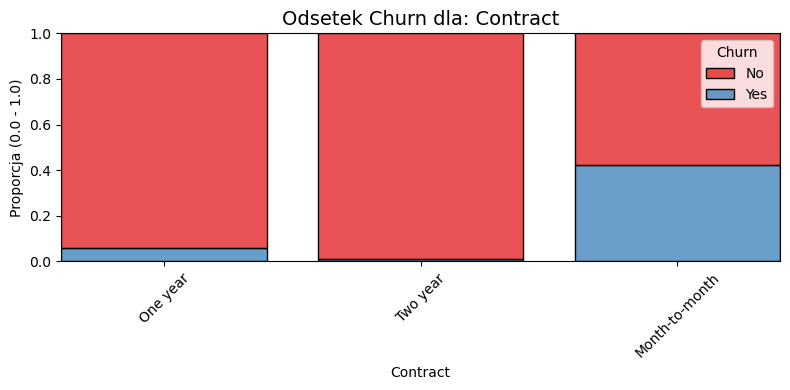

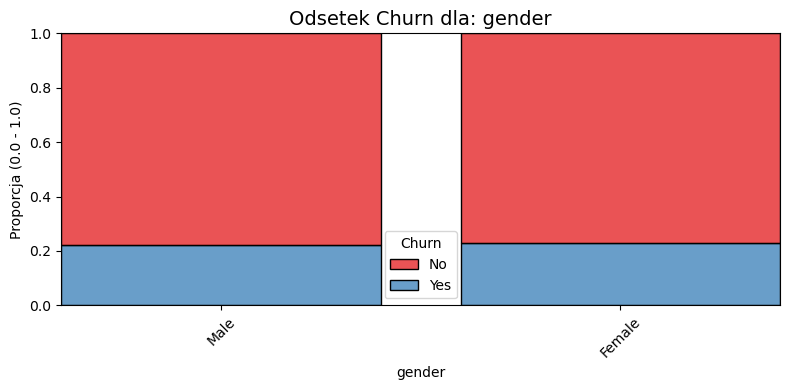

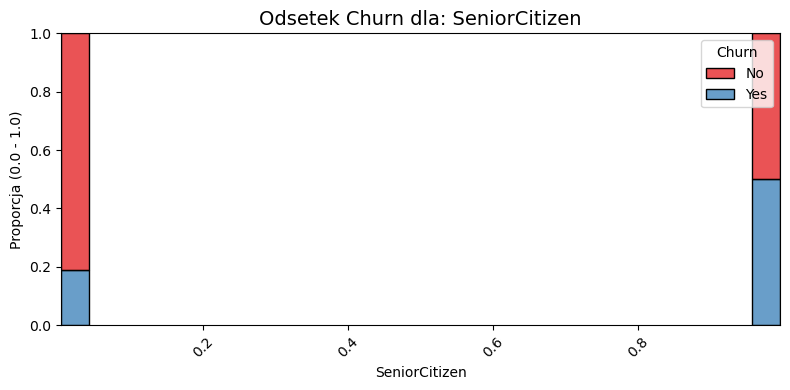

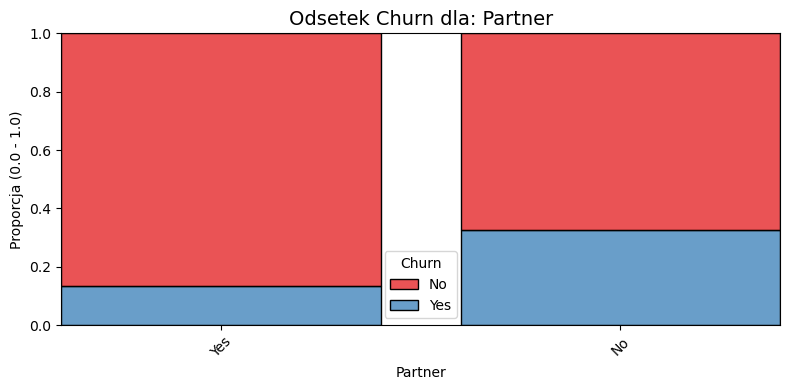

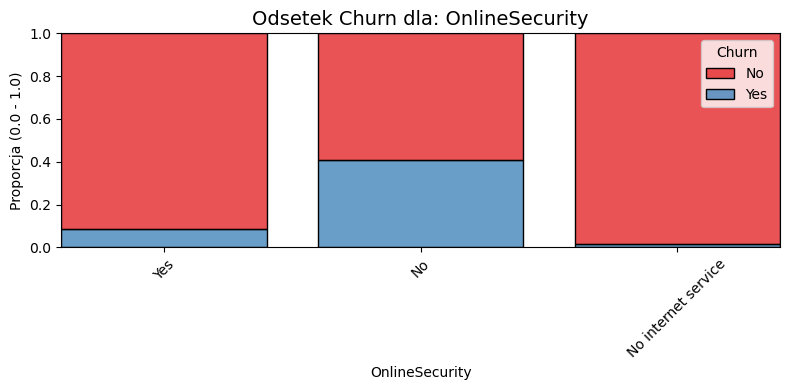

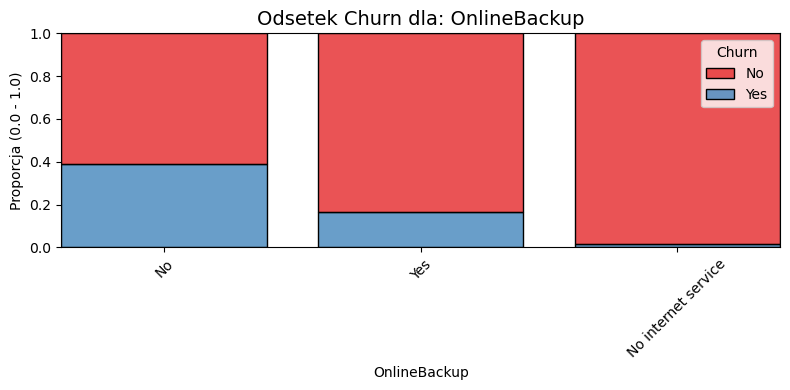

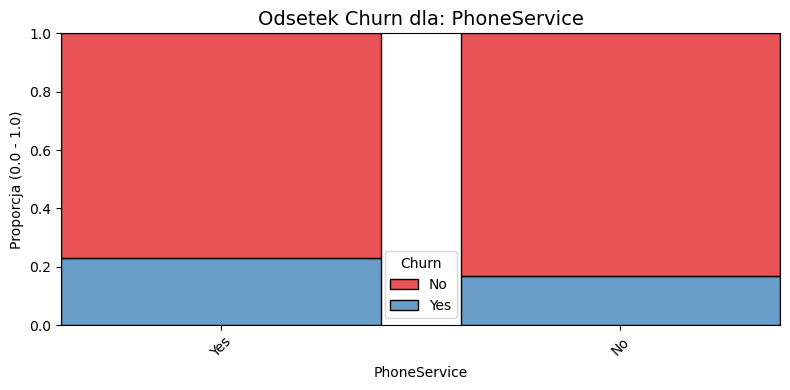

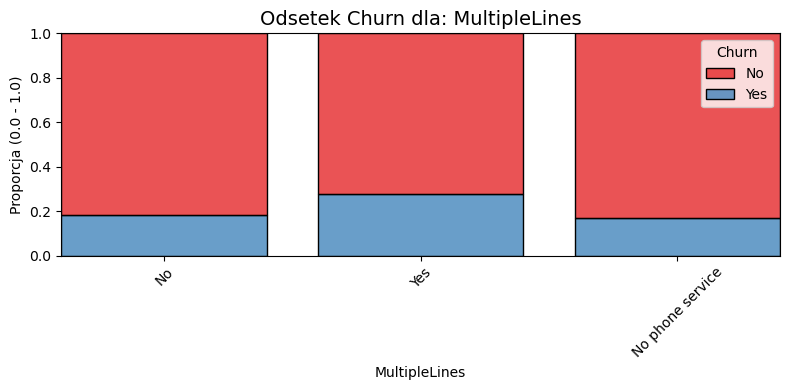

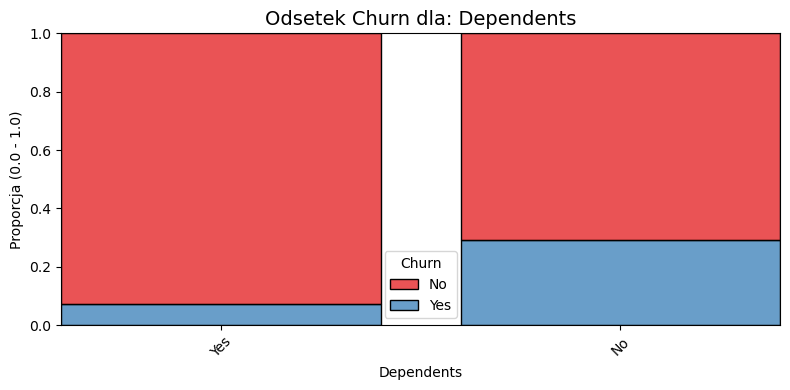

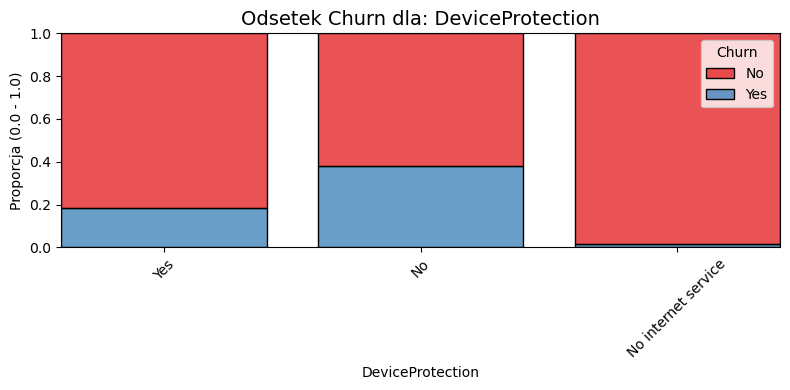

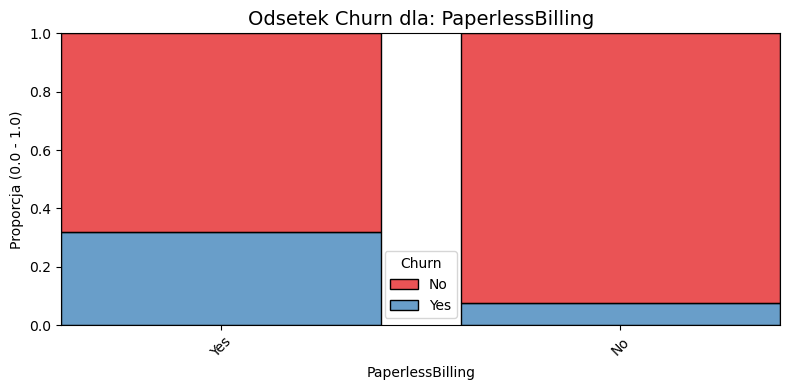

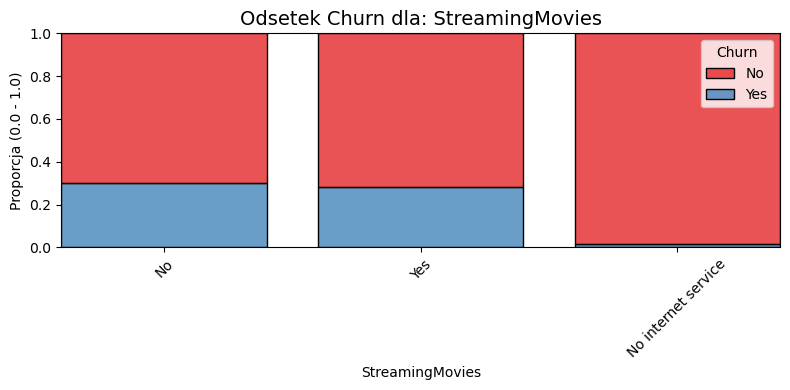

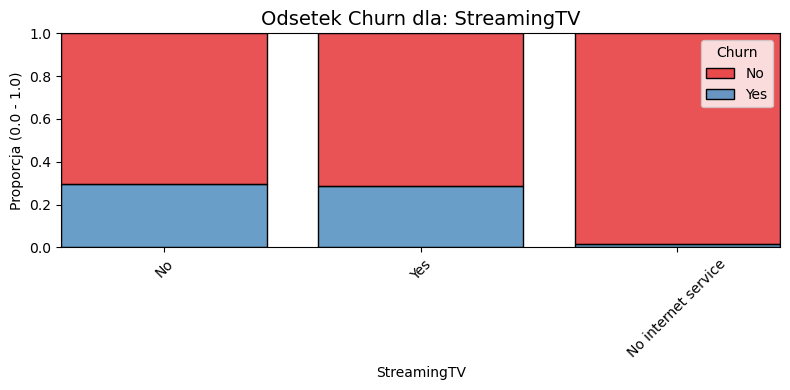

In [21]:
for kolumna in zmienne_do_testu:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=train_eda, 
        x=kolumna, 
        hue='Churn', 
        multiple="fill", 
        shrink=.8, 
        palette='Set1' 
    )
    
    plt.title(f'Odsetek Churn dla: {kolumna}', fontsize=14)
    plt.ylabel('Proporcja (0.0 - 1.0)')
    plt.xlabel(kolumna)

    plt.xticks(rotation=45) 

    plt.tight_layout()
    plt.show()

In [22]:
for kolumna in set(zmienne_do_testu): 
    print(f"--- {kolumna} ---")

    udzial_procentowy = (train_eda[kolumna].value_counts(normalize=True) * 100).round(2)

    for kategoria, procent in udzial_procentowy.items():
        print(f"{kategoria}: {procent}%")
        
    print("\n")

--- StreamingMovies ---
Yes: 40.63%
No: 35.68%
No internet service: 23.68%


--- StreamingTV ---
Yes: 40.44%
No: 35.87%
No internet service: 23.68%


--- InternetService ---
Fiber optic: 45.84%
DSL: 30.48%
No: 23.68%


--- DeviceProtection ---
No: 41.63%
Yes: 34.68%
No internet service: 23.68%


--- Partner ---
Yes: 52.1%
No: 47.9%


--- Dependents ---
No: 69.74%
Yes: 30.26%


--- PaymentMethod ---
Electronic check: 36.25%
Credit card (automatic): 22.5%
Mailed check: 20.83%
Bank transfer (automatic): 20.42%


--- TechSupport ---
No: 48.57%
Yes: 27.75%
No internet service: 23.68%


--- Contract ---
Month-to-month: 50.31%
Two year: 31.46%
One year: 18.23%


--- SeniorCitizen ---
0: 88.59%
1: 11.41%


--- OnlineSecurity ---
No: 48.72%
Yes: 27.6%
No internet service: 23.68%


--- OnlineBackup ---
No: 42.09%
Yes: 34.23%
No internet service: 23.68%


--- PhoneService ---
Yes: 93.89%
No: 6.11%


--- MultipleLines ---
No: 47.69%
Yes: 46.2%
No phone service: 6.11%


--- PaperlessBilling ---
Yes

#### Zmienne, które pojedynczo nie mają żadnego wpływu na Churn (można potem rozważyć ich interakcje):
- StreamingTV
- StreamingMovies
- MultipleLines
- PhoneService
- gender

Najbardziej widoczne zależności dla Contract i Payment Method

## Pomysły na interakcje cech i nowe zmienne:
- Liczba usług: zsumować kolumny typu 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'
- Partner + Dependents - wielkość rodziny
- binning zmiennej tenure ze zmienną Contract
- Phone Service + Internet Service
- Paperless billing + SeniorCitizen
- TotalCharges - MonthlyCharges * tenure 

In [23]:
weak_features = ['StreamingTV', 'StreamingMovies', 'MultipleLines', 'PhoneService', 'gender']
df_inter = train_eda.copy()

for col in weak_features:
    if col == 'gender':
        df_inter[col] = df_inter[col].map({'Female': 1, 'Male': 0})
    else:
        df_inter[col] = df_inter[col].apply(lambda x: 1 if x == 'Yes' else 0)

df_inter['Churn_num'] = df_inter['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)



   id  gender  SeniorCitizen Partner Dependents  tenure  PhoneService  \
0   0       0              0     Yes        Yes      29             1   
1   1       0              0     Yes        Yes      58             1   
2   2       0              0     Yes         No      58             1   
3   3       1              0      No         No       1             1   
4   4       1              0      No         No       1             1   

   MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0              0             DSL            Yes  ...           0   
1              0             DSL            Yes  ...           1   
2              1     Fiber optic             No  ...           1   
3              0     Fiber optic             No  ...           0   
4              0     Fiber optic             No  ...           0   

  StreamingMovies        Contract  PaperlessBilling            PaymentMethod  \
0               0        One year               Yes             Mailed c

In [30]:

def test_features(feature_list, name, X_train, X_val, y_train, y_val):
    rf = RandomForestClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
    rf.fit(X_train[feature_list], y_train)
    probs = rf.predict_proba(X_val[feature_list])[:, 1]
    auc = roc_auc_score(y_val, probs)
    return auc



In [31]:
df_model = df_inter.copy()
y = df_inter['Churn_num']

df_model['Contract_Month'] = (df_model['Contract'] == 'Month-to-month').astype(int)
df_model['Fiber_Optic'] = (df_model['InternetService'] == 'Fiber optic').astype(int)

base_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month', 'Fiber_Optic']
weak_vars = ['StreamingTV', 'StreamingMovies', 'MultipleLines', 'PhoneService', 'gender']

X_train_m, X_val_m, y_train_m, y_val_m = train_test_split(df_model, y, test_size=0.2, random_state=42)


baseline_auc = test_features(base_features, "BASE", X_train_m, X_val_m, y_train_m, y_val_m)
print(f"ROC AUC Modelu Bazowego: {baseline_auc:.5f}")
print("-" * 70)

all_results = []

ROC AUC Modelu Bazowego: 0.90250
----------------------------------------------------------------------


Wybór zmiennych base na podstawie ich "ważności" + LLM wspomniał, że Fiber_Optic i Month-to-Month są ważne co w sumie też widać na pracy Piotra

In [34]:
for r in [2, 3, 4]:
    print(f"Testowanie interakcji rzędu {r}...")
    for combo in combinations(weak_vars, r):
        inter_name = "INTER_" + "_".join([v[:3] for v in combo])
        
        df_model[inter_name] = df_model[list(combo)].prod(axis=1)
        
        current_features = base_features + list(combo) + [inter_name]
        
        X_tr, X_val = train_test_split(df_model, test_size=0.2, random_state=42)
        
        auc = test_features(current_features, inter_name, X_tr, X_val, y_train_m, y_val_m)
        
        all_results.append({
            'name': " x ".join(combo),
            'auc': auc,
            'order': r
        })

print("\n" + "="*70)
print("TOP 10 INTERAKCJI (Względem poprawy AUC):")
ranked = sorted(all_results, key=lambda x: x['auc'], reverse=True)

for i, res in enumerate(ranked[:10]):
    improvement = res['auc'] - baseline_auc
    print(f"{i+1}. [Rząd {res['order']}] {res['name']}")
    print(f"   AUC: {res['auc']:.5f} (Poprawa: {improvement:+.5f})")

Testowanie interakcji rzędu 2...
Testowanie interakcji rzędu 3...
Testowanie interakcji rzędu 4...

TOP 10 INTERAKCJI (Względem poprawy AUC):
1. [Rząd 4] StreamingTV x StreamingMovies x MultipleLines x PhoneService
   AUC: 0.90462 (Poprawa: +0.00211)
2. [Rząd 3] StreamingTV x StreamingMovies x MultipleLines
   AUC: 0.90448 (Poprawa: +0.00197)
3. [Rząd 3] StreamingTV x MultipleLines x PhoneService
   AUC: 0.90417 (Poprawa: +0.00167)
4. [Rząd 4] StreamingTV x StreamingMovies x MultipleLines x gender
   AUC: 0.90402 (Poprawa: +0.00151)
5. [Rząd 3] StreamingTV x StreamingMovies x PhoneService
   AUC: 0.90394 (Poprawa: +0.00144)
6. [Rząd 2] StreamingTV x MultipleLines
   AUC: 0.90372 (Poprawa: +0.00121)
7. [Rząd 3] StreamingMovies x MultipleLines x PhoneService
   AUC: 0.90370 (Poprawa: +0.00120)
8. [Rząd 2] StreamingTV x StreamingMovies
   AUC: 0.90358 (Poprawa: +0.00108)
9. [Rząd 3] StreamingTV x MultipleLines x gender
   AUC: 0.90357 (Poprawa: +0.00107)
10. [Rząd 4] StreamingTV x Multipl

Za bardzo nic w tym nie widać po za tym, że StreamingTV to jest najlepsza z najgorszych, a potem SteaminMovies , reszta raczej słaba mało znacząca.